<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/hebbian_ihd_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hebbian Inverse-Heat-Dissipation Diffusion
### a ~9.45M-param diffusion model trained with a **purely local Hebbian rule --- no autograd backward**

**Thesis.** Corrupt an image by running the *heat equation* forward (it blurs); the
generative model learns the **inverse** (deblur). The heat semigroup **factorizes**
exactly in the DCT eigenbasis, $e^{t\Delta}=C^\top\,\mathrm{diag}(e^{-t\lambda_k})\,C$ ---
a per-mode decay, i.e. a genuine **convolution** with the heat kernel. The denoiser is a
**weight-tied convolutional fixed-point net**; its credit is computed with **no backprop**
by a second, forward-style **adjoint relaxation** (recurrent backpropagation / Almeida--Pineda),
and every weight gradient falls out as a **Hebbian outer product** (forward activity $\otimes$ adjoint error).

| you asked for | it is | where |
|---|---|---|
| diffusion model | inverse heat dissipation (blur $\leftrightarrow$ deblur) | `HeatOperator`, training cell |
| convolution / factorizing | $e^{t\Delta}=C^\top\mathrm{diag}(e^{-t\lambda})C$ | `HeatOperator` |
| Hebbian weighting, no backprop | Almeida--Pineda adjoint $\to$ outer-product grads | `stage_backward`, `loss_and_grads` |
| Poisson **sampling** | diffusion level $\sim$ Poisson process | `poisson_sample_level` |
| Poisson **equation** | screened-Poisson resolvent $1/(1+t\lambda_k)$ + $L[u_t]$ feature | `screened_poisson`, `laplacian` |
| relatively big model | C=256, 8 tied stages, depth 24, ~9.45M | `big_config` |

> Runs on Apple **MPS**, CUDA, or CPU. A few ops (`logspace`,`poisson`,`linspace`) are built on CPU and moved.

## 0 --- Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')  # must precede torch import
import math, time, json
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn.grad import conv2d_weight
import matplotlib.pyplot as plt

def get_device():
    if torch.backends.mps.is_available(): return torch.device('mps')
    if torch.cuda.is_available():        return torch.device('cuda')
    return torch.device('cpu')
device = get_device()
print('torch', torch.__version__, '| device', device)

torch 2.11.0+cu128 | device cuda


## 1 --- Forward corruption: Inverse Heat Dissipation, factorized
The heat semigroup diagonalizes in the DCT basis, so a whole 2-D blur is *DCT $\to$ multiply
by $e^{-t(\lambda_i+\lambda_j)}$ $\to$ iDCT* (dense 32x32 matmuls, no FFT). `laplacian` and
`screened_poisson` expose the known operator as a free feature / preconditioner.

In [2]:
"""
heat.py --- Inverse Heat Dissipation forward process (the "diffusion" corruption),
            written so the heat semigroup FACTORIZES exactly in the DCT eigenbasis.
============================================================================

WHY THIS FILE EXISTS
--------------------
A standard diffusion model corrupts data by ADDING Gaussian noise.  This model
corrupts data by DISSIPATING it through the heat equation

        d u / d t  =  Delta u ,            u(., 0) = u0   (a clean image)

i.e. the forward process is *blurring*, and the generative model learns the
INVERSE (deblurring) map.  This is "Inverse Heat Dissipation" (Rissanen, Heljakka,
Kannala 2022), and it is the honest reading of the user's phrase
"Inverse Heating Dissipation factorizing".

THE FACTORIZATION (the whole point)
-----------------------------------
On a finite grid with Neumann (reflecting) boundaries, the discrete Laplacian is
diagonalized by the Discrete Cosine Transform (DCT-II).  The heat semigroup is

        e^{t Delta}  =  C^T  diag( e^{-t lambda_k} )  C ,

with C the (orthonormal) DCT matrix and lambda_k the Laplacian eigenvalues.  In
2-D the eigenvalues separate, lambda_{ij} = lambda_i + lambda_j, so a whole
2-D blur is just:

        DCT  ->  multiply by the separable mask exp(-t (lambda_i + lambda_j))  ->  iDCT.

That "multiply by a per-mode decay" IS the factorization.  It also makes the
process a genuine CONVOLUTION (the heat kernel / Green's function of Delta), which
is the "Convolution technique" the user asked for, realized *without* any FFT
(pure dense 32x32 matmuls -- MPS-friendly, no torch.fft dependence).

Cross-links to the wider program:
  * lambda_k here are exactly the poles of the [[laplace-greens-hebbian-net]]:
    the reverse step is a screened-Poisson solve 1/(1 + t*lambda_k) in the SAME
    eigenbasis (see `screened_poisson`), i.e. the known operator is a FREE
    preconditioner (the [[operator-preconditioned-forward-only-cap]] pivot).
  * "Poisson Sampling": diffusion time is drawn from a Poisson process over the
    blur ladder (see `poisson_sample_level`), not a uniform grid.

Everything is float32 and device-agnostic (CPU or MPS).
"""
from __future__ import annotations
import math
import torch


# ----------------------------------------------------------------------------
# DCT-II eigenbasis of the 1-D Neumann Laplacian (built once, cached per size)
# ----------------------------------------------------------------------------
def dct_matrix(n: int, device, dtype=torch.float32) -> torch.Tensor:
    """Orthonormal DCT-II matrix C  (n x n).  Rows are the Neumann-Laplacian
    eigenvectors; C @ x transforms a length-n signal into cosine-mode space."""
    k = torch.arange(n, device=device, dtype=dtype).view(n, 1)   # frequency index
    x = torch.arange(n, device=device, dtype=dtype).view(1, n)   # spatial index
    C = torch.cos(math.pi * (2.0 * x + 1.0) * k / (2.0 * n))
    C[0, :] *= 1.0 / math.sqrt(2.0)                               # DC normalization
    C *= math.sqrt(2.0 / n)
    return C                                                      # orthonormal: C C^T = I


def laplacian_eigenvalues(n: int, device, dtype=torch.float32) -> torch.Tensor:
    """Eigenvalues (>=0) of the 1-D discrete Neumann Laplacian -Delta on n nodes:
        lambda_k = 2 - 2 cos(pi k / n) = (2 sin(pi k / 2n))^2 ,   k = 0..n-1.
    lambda_0 = 0 is the conserved-mean (DC) mode -- the heat process pushes every
    image toward its own spatial mean, which is why the generative prior is
    'mean image + small noise'."""
    k = torch.arange(n, device=device, dtype=dtype)
    return (2.0 * torch.sin(math.pi * k / (2.0 * n))) ** 2


class HeatOperator:
    """Factorized heat dissipation on an (H x W) grid.  Caches the DCT matrices and
    the separable eigenvalue grid so every blur is three small matmuls + one mask
    multiply.  Also exposes the discrete Laplacian (the 'known operator' feature)
    and the screened-Poisson resolvent (the free preconditioner)."""

    def __init__(self, H: int, W: int, device, dtype=torch.float32):
        self.H, self.W, self.device, self.dtype = H, W, device, dtype
        self.Ch = dct_matrix(H, device, dtype)                   # (H,H)
        self.Cw = dct_matrix(W, device, dtype)                   # (W,W)
        lam_h = laplacian_eigenvalues(H, device, dtype).view(H, 1)
        lam_w = laplacian_eigenvalues(W, device, dtype).view(1, W)
        self.Lam = lam_h + lam_w                                 # (H,W) 2-D eigenvalues
        self.lam_max = float(self.Lam.max())

    # -- DCT / inverse DCT on a batch of images x: (B, C, H, W) ----------------
    def dct2(self, x: torch.Tensor) -> torch.Tensor:
        # apply C along H (rows) and W (cols): Ch @ x @ Cw^T
        return torch.einsum("hi,bcij,wj->bchw", self.Ch, x, self.Cw)

    def idct2(self, X: torch.Tensor) -> torch.Tensor:
        # inverse is the transpose (orthonormal): x = Ch^T @ X @ Cw.  Ch/Cw are
        # [freq, space], so contract the FREQ index (h,w) on each side.
        return torch.einsum("hi,bchw,wj->bcij", self.Ch, X, self.Cw)

    # -- the forward corruption: u(t) = e^{t Delta} u0 -------------------------
    def blur(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """Dissipate x for continuous time t (per-sample, shape (B,) or scalar).
        Exact heat-semigroup solution via the factorization."""
        X = self.dct2(x)
        t = t.view(-1, 1, 1, 1) if torch.is_tensor(t) and t.ndim else t
        decay = torch.exp(-t * self.Lam)                         # (B,1,H,W) broadcast
        return self.idct2(X * decay)

    def laplacian(self, x: torch.Tensor) -> torch.Tensor:
        """Apply the discrete Laplacian  -Delta x  in the eigenbasis (exact).
        Used as an extra INPUT CHANNEL to the denoiser: injecting L[u_t] is the
        'operator-corrected forward feature' that lifts the naive-Hebbian subspace
        overlap ~0.72 -> ~1.0 in rung01 -- a free whitener."""
        return self.idct2(self.dct2(x) * self.Lam)

    def screened_poisson(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """Resolvent (I + t (-Delta))^{-1} x  == solve the screened-Poisson /
        implicit-heat system, diagonal in the eigenbasis: multiply by
        1 / (1 + t lambda_k).  This is the operator-preconditioned reverse step:
        every mode gets 1/(1 + t lambda_k), the pole structure of the Green's net."""
        t = t.view(-1, 1, 1, 1) if torch.is_tensor(t) and t.ndim else t
        return self.idct2(self.dct2(x) / (1.0 + t * self.Lam))


# ----------------------------------------------------------------------------
# The blur LADDER + POISSON SAMPLING of diffusion time
# ----------------------------------------------------------------------------
def make_blur_ladder(num_steps: int, t_min: float, t_max: float, device,
                     dtype=torch.float32) -> torch.Tensor:
    """Geometric (log-spaced) ladder of dissipation times t_0=0 < t_1 < ... < t_L.
    Log spacing = equal *multiplicative* blur per step, the natural schedule for a
    semigroup whose modes decay as exp(-t lambda)."""
    # built on CPU (MPS lacks logspace) then moved -- tiny, done once.
    ts = torch.logspace(math.log10(t_min), math.log10(t_max), num_steps, dtype=dtype)
    ladder = torch.cat([torch.zeros(1, dtype=dtype), ts])                # length L+1
    return ladder.to(device)


def poisson_sample_level(batch: int, num_levels: int, device,
                         rate: float = 1.0, generator=None) -> torch.Tensor:
    """POISSON SAMPLING of the diffusion level index in {1, ..., num_levels}.

    Instead of a uniform integer level, we place the training level by a Poisson
    process: draw N ~ Poisson(rate) increments and read off the level, which
    concentrates samples the way a Poisson jump process would traverse the blur
    ladder (more mass at low levels, a fat tail toward heavy blur).  Values are
    clamped to [1, num_levels].  This is the literal 'Poisson Sampling' knob; the
    Poisson-*equation* connection lives in HeatOperator.screened_poisson.
    """
    # exponential inter-arrival -> Poisson counts; +1 keeps level >= 1.
    # sampled on CPU (MPS lacks torch.poisson) then moved -- tiny, per-step.
    lam = torch.full((batch,), float(rate))
    counts = torch.poisson(lam, generator=generator).long() + 1
    return counts.clamp_(1, num_levels).to(device)

## 2 --- Backprop-free credit: weight-tied cell + adjoint = Hebbian
The cell $z_{k+1}=z_k+\alpha\,W_2*\phi(W_1*z_k+\mathrm{inj})$ is relaxed for $T$ steps.
Credit comes from the transposed-Jacobian relaxation (conv-**transpose** + pointwise $\phi'$),
and each weight gradient is `conv2d_weight(input, grad_output)` --- a Hebbian correlation.
Nothing here builds an autograd graph.

In [3]:
"""
hebbian_deq.py --- The backprop-free credit engine.
===================================================

WHAT THIS IS
------------
The denoiser is built from weight-TIED convolutional fixed-point cells

        z_{k+1} = z_k + alpha * W2 * phi( W1 * z_k + inj ) ,     k = 0..T-1        (1)

(* = 2-D convolution, phi = tanh).  Running (1) is a truncated relaxation toward a
fixed point z* = g_W(z*); the T-step unroll is a weight-tied "fixed-point net"
(the [[laplace-greens-hebbian-net]] object).

CREDIT WITHOUT BACKPROP
-----------------------
We never call loss.backward().  Instead we compute the exact gradient by a SECOND
relaxation with the transposed Jacobian (recurrent backpropagation / Almeida-
Pineda 1987; the Hebbian two-phase reading is Equilibrium Propagation).  For (1)
the transposed-Jacobian step is

        g_k  =  g_{k+1}  +  alpha * W1^T * [ phi'(pre_k) (.) W2^T * g_{k+1} ]        (2)

which uses only conv-TRANSPOSE (W^T *) and a pointwise phi' -- i.e. the SAME
primitives as the forward pass, run forward in relaxation time.  Summing the
truncated series (2) applies the truncated resolvent (I - J^T)^{-1}; that is the
"resolvent == exact backprop credit" claim, and rulers.py checks it against
autograd (cosine ~ 1.0).

THE UPDATE IS LITERALLY HEBBIAN
-------------------------------
Each weight's gradient is a CORRELATION between the forward activity on its input
side and the adjoint (error) activity on its output side -- a pre(.)post outer
product, summed over the relaxation and the batch:

        dL/dW2 = corr( h_k ,           alpha * g_{k+1} )      (hidden  x  error)
        dL/dW1 = corr( z_k , phi'(pre_k)(.)(W2^T g_{k+1}) )   (state   x  local error)

For convolutions that correlation is exactly torch.nn.grad.conv2d_weight -- a
direct, tape-free computation.  No autograd graph is ever built (the model runs
these under torch.no_grad()).

Everything below is plain tensor ops so the SAME forward can be re-run under
autograd for the ruler; only the *backward* differs (manual vs. autograd).
"""
from __future__ import annotations
from dataclasses import dataclass
import torch
import torch.nn.functional as F
from torch.nn.grad import conv2d_weight


# ---- pointwise nonlinearity and its derivative (in terms of the OUTPUT) ------
def phi(x: torch.Tensor) -> torch.Tensor:
    return torch.tanh(x)


def dphi_from_out(h: torch.Tensor) -> torch.Tensor:
    return 1.0 - h * h                      # tanh'(x) = 1 - tanh(x)^2


# ---- single-conv tape-free VJPs (the primitives of the adjoint relaxation) ---
def conv_vjp_input(grad_out: torch.Tensor, weight: torch.Tensor, pad: int) -> torch.Tensor:
    """dL/d(input) of  y = conv2d(input, weight, padding=pad), stride 1.  Exactly a
    conv-transpose -- the 'W^T *' operator.  Tape-free."""
    return F.conv_transpose2d(grad_out, weight, padding=pad)


def conv_vjp_weight(inp: torch.Tensor, grad_out: torch.Tensor, weight_size, pad: int) -> torch.Tensor:
    """dL/d(weight) == correlation of the forward input with the output-side error.
    This is the Hebbian outer product for a conv layer.  Sums over the batch."""
    return conv2d_weight(inp, weight_size, grad_out, stride=1, padding=pad,
                         dilation=1, groups=1)


# ----------------------------------------------------------------------------
# A weight-tied residual conv cell (one "stage") + its forward relaxation
# ----------------------------------------------------------------------------
@dataclass
class StageCache:
    z: list          # z_0 .. z_T           (states)
    h: list          # h_0 .. h_{T-1}       (hidden activities phi(pre_k))


def stage_forward(z0: torch.Tensor, inj: torch.Tensor,
                  W1: torch.Tensor, W2: torch.Tensor,
                  T: int, alpha: float, pad: int) -> tuple[torch.Tensor, StageCache]:
    """Run the tied relaxation (1) for T steps.  Returns z_T and the cache needed
    by the manual adjoint.  Pure ops -> also autograd-differentiable (ruler reuse)."""
    z = z0
    zs, hs = [z0], []
    for _ in range(T):
        pre = F.conv2d(z, W1, padding=pad) + inj
        h = phi(pre)
        z = z + alpha * F.conv2d(h, W2, padding=pad)
        zs.append(z)
        hs.append(h)
    return z, StageCache(z=zs, h=hs)


def stage_backward(g_zT: torch.Tensor, cache: StageCache,
                   W1: torch.Tensor, W2: torch.Tensor,
                   T: int, alpha: float, pad: int,
                   fb_W1: torch.Tensor = None, fb_W2: torch.Tensor = None):
    """The adjoint relaxation (2), tape-free.  Given dL/dz_T, return
        (dL/dz_0, dL/dW1, dL/dW2, dL/d inj).
    dL/dW1, dL/dW2 are Hebbian correlations summed over the T steps and the batch;
    dL/d inj is summed over the T steps (inj is re-injected every step).

    `fb_W1`, `fb_W2` are the FEEDBACK weights used to *route* credit (the transposed
    convs).  Default = the forward weights -> the EXACT adjoint == backprop (R0).
    Pass fixed RANDOM feedback -> Feedback Alignment (backprop-free but approximate):
    the credit is routed through random weights while the Hebbian outer products
    still correlate forward activity with the delivered error."""
    fbW1 = W1 if fb_W1 is None else fb_W1
    fbW2 = W2 if fb_W2 is None else fb_W2
    gW1 = torch.zeros_like(W1)
    gW2 = torch.zeros_like(W2)
    g_inj = torch.zeros_like(g_zT)
    g = g_zT
    for k in range(T - 1, -1, -1):
        z_k = cache.z[k]
        h_k = cache.h[k]
        a = alpha * g                                  # error entering the W2 conv
        # -- W2 path: z_{k+1} = z_k + alpha * conv(h_k, W2)
        gW2 += conv_vjp_weight(h_k, a, W2.shape, pad)  # Hebbian: corr(hidden, error)
        gh = conv_vjp_input(a, fbW2, pad)              # route dL/dh_k (exact: W2; FA: random)
        # -- nonlinearity
        gpre = gh * dphi_from_out(h_k)                 # dL/dpre_k
        # -- injection is added into pre each step
        g_inj = g_inj + gpre
        # -- W1 path: pre_k = conv(z_k, W1) + inj
        gW1 += conv_vjp_weight(z_k, gpre, W1.shape, pad)   # Hebbian: corr(state, local error)
        gz = conv_vjp_input(gpre, fbW1, pad)           # route dL/dz_k (exact: W1; FA: random)
        # -- identity skip (z_{k+1} = z_k + ...)
        g = g + gz
    return g, gW1, gW2, g_inj


# ----------------------------------------------------------------------------
# Diagnostics for the "stay off the poles" stability story
# ----------------------------------------------------------------------------
@torch.no_grad()
def cell_jacobian_radius(W1: torch.Tensor, W2: torch.Tensor, inj: torch.Tensor,
                         z: torch.Tensor, alpha: float, pad: int,
                         iters: int = 12) -> float:
    """Power-iterate the spectral radius of the cell Jacobian J = d g_W / d z at a
    point (via J v ~ finite differences using the transposed/forward convs).  The
    truncated resolvent (I - J)^{-1} converges iff rho(J) < 1: 'stability = stay off
    the poles 1/(1 - mu_k)'.  Returns an estimate of rho(alpha * W2 diag(phi') W1)."""
    v = torch.randn_like(z)
    v = v / (v.norm() + 1e-12)
    pre = F.conv2d(z, W1, padding=pad) + inj
    dp = dphi_from_out(phi(pre))
    lam = 0.0
    for _ in range(iters):
        Jv = alpha * F.conv2d(dp * F.conv2d(v, W1, padding=pad), W2, padding=pad)
        lam = float(Jv.norm())
        v = Jv / (Jv.norm() + 1e-12)
    return lam

## 3 --- The ~9.45M-param denoiser
Encoder injects $u_t$ **and** its Laplacian $L[u_t]$ (the free operator feature); a stack of
tied stages relaxes to $z^\*$; a sigmoid readout predicts the clean image. `loss_and_grads`
returns the loss **and every gradient with no `.backward()`** (all under `torch.no_grad()`).

In [4]:
"""
model.py --- The (relatively big) Hebbian Inverse-Heat-Dissipation denoiser.
============================================================================

ARCHITECTURE
------------
                 u_t (blurred)  ---.
                                    |  cat with L[u_t]  (the KNOWN operator feature,
                 L[u_t] = -Delta u  |  a free whitener -- see heat.HeatOperator)
                                    v
   time t --> sinusoidal --> Linear -+->  ENCODER conv --> inj  (B,C,H,W)
                                          |
                        z_0 = 0  -->  [ tied stage 1 ] -> [ tied stage 2 ] -> ... -> z*
                                          (each stage = T steps of the weight-tied
                                           residual conv cell in hebbian_deq.py)
                                          |
                                       DECODER conv --> u0_hat = u_t + correction  (identity skip)

    loss = mean( (u0_hat - u0)^2 )     (learn the deblurring CORRECTION on top of u_t; the
                                        skip makes light blur nearly free at init)

CREDIT ASSIGNMENT
-----------------
`loss_and_grads` computes the loss and EVERY parameter gradient with NO autograd:
the decoder VJP seeds an adjoint that relaxes back down the stages
(hebbian_deq.stage_backward), and the encoder / time-embedding gradients are the
boundary correlations.  Each gradient is a Hebbian outer product.  The whole thing
runs under torch.no_grad() so no graph can exist.  `autograd_reference` re-runs the
SAME forward with autograd purely so rulers.py can check the two agree.  Passing
`feedback=` fixed random weights to `loss_and_grads` routes credit through them
(Feedback Alignment) instead of the transposed forward weights.

SIZE
----
Dominant term ~ 18 * S * C^2.  The `big` config (C=256, S=8) is ~9.4M parameters.
"""
from __future__ import annotations
from dataclasses import dataclass
import math
import torch
import torch.nn.functional as F

# phi, stage_forward, stage_backward, conv_vjp_input, conv_vjp_weight
# are defined in the hebbian_deq cell above.


# ----------------------------------------------------------------------------
@dataclass
class Config:
    C: int = 256           # feature width
    S: int = 8             # number of tied stages
    T: int = 3             # relaxation steps per stage (effective depth S*T)
    alpha: float = 0.5     # residual step size (contraction knob -> stay off the poles)
    in_extra_laplacian: bool = True
    Ftime: int = 32        # sinusoidal time-embedding dimension
    pad: int = 1           # 3x3 'same' convs everywhere
    kernel: int = 3

    @property
    def in_ch(self) -> int:
        return 2 if self.in_extra_laplacian else 1


def big_config() -> Config:
    return Config(C=256, S=8, T=3)          # ~9.4M params, MPS-runnable


def demo_config() -> Config:
    return Config(C=96, S=4, T=3)           # ~0.6M params, fast smoke tests


# ----------------------------------------------------------------------------
def _conv_w(out_ch, in_ch, k, scale, device):
    w = torch.randn(out_ch, in_ch, k, k, device=device) * scale
    return torch.nn.Parameter(w, requires_grad=False)   # grads are set MANUALLY


class HebbianIHDNet:
    """Holds parameters as (grad-less) tensors; gradients are filled in by hand and
    consumed by a hand-rolled optimizer.  Not an nn.Module -- we deliberately avoid
    autograd bookkeeping so 'no backward' is structural, not a promise."""

    def __init__(self, cfg: Config, device):
        self.cfg, self.device = cfg, device
        C, k, pad = cfg.C, cfg.kernel, cfg.pad
        fan = C * k * k
        s_cell = 0.5 / math.sqrt(fan)                    # contractive init for the cell
        # encoder: (in_ch -> C)
        self.enc_W = _conv_w(C, cfg.in_ch, k, 1.0 / math.sqrt(cfg.in_ch * k * k), device)
        self.enc_b = torch.nn.Parameter(torch.zeros(C, device=device), requires_grad=False)
        # time embedding: sinusoidal(Ftime) -> C bias
        self.temb_W = torch.nn.Parameter(
            torch.randn(C, cfg.Ftime, device=device) * (1.0 / math.sqrt(cfg.Ftime)),
            requires_grad=False)
        self.temb_b = torch.nn.Parameter(torch.zeros(C, device=device), requires_grad=False)
        # tied stages
        self.W1 = [_conv_w(C, C, k, s_cell, device) for _ in range(cfg.S)]
        self.W2 = [_conv_w(C, C, k, s_cell, device) for _ in range(cfg.S)]
        # decoder: (C -> 1)
        self.dec_W = _conv_w(1, C, k, 1.0 / math.sqrt(fan), device)
        self.dec_b = torch.nn.Parameter(torch.zeros(1, device=device), requires_grad=False)
        # time-embedding frequencies (built on CPU -- MPS lacks linspace -- then moved)
        half = cfg.Ftime // 2
        self.time_freqs = torch.exp(torch.linspace(0, math.log(1000.0), half)).to(device)

    # -- parameter bookkeeping -------------------------------------------------
    def params(self) -> dict:
        d = {"enc_W": self.enc_W, "enc_b": self.enc_b,
             "temb_W": self.temb_W, "temb_b": self.temb_b,
             "dec_W": self.dec_W, "dec_b": self.dec_b}
        for s in range(self.cfg.S):
            d[f"W1_{s}"] = self.W1[s]
            d[f"W2_{s}"] = self.W2[s]
        return d

    def num_params(self) -> int:
        return sum(p.numel() for p in self.params().values())

    def make_feedback(self, seed=0) -> dict:
        """Fixed RANDOM feedback weights (one per credit-routing conv), matching the
        forward-weight shapes.  Used by Feedback Alignment to route credit WITHOUT the
        transpose of the forward weights.  Never updated."""
        g = torch.Generator(device="cpu").manual_seed(seed)
        fb = {}
        for name in ["dec_W"] + [f"W1_{s}" for s in range(self.cfg.S)] + \
                    [f"W2_{s}" for s in range(self.cfg.S)]:
            w = self.params()[name]
            fb[name] = (torch.randn(w.shape, generator=g) * (0.5 / math.sqrt(w.shape[1] * w.shape[2] * w.shape[3]))).to(self.device)
        return fb

    # -- time features ---------------------------------------------------------
    def time_features(self, t: torch.Tensor) -> torch.Tensor:
        """Sinusoidal embedding of continuous dissipation time t (shape (B,))."""
        ang = t.view(-1, 1) * self.time_freqs.view(1, -1)
        return torch.cat([torch.sin(ang), torch.cos(ang)], dim=1)     # (B, Ftime)

    # -- forward (no autograd) -------------------------------------------------
    @torch.no_grad()
    def forward(self, u_t: torch.Tensor, t: torch.Tensor, heat):
        cfg = self.cfg
        if cfg.in_extra_laplacian:
            feat = torch.cat([u_t, heat.laplacian(u_t)], dim=1)
        else:
            feat = u_t
        tfeat = self.time_features(t)                                  # (B,Ftime)
        tbias = (tfeat @ self.temb_W.t() + self.temb_b).view(-1, cfg.C, 1, 1)
        inj = F.conv2d(feat, self.enc_W, padding=cfg.pad) + self.enc_b.view(1, -1, 1, 1) + tbias
        z = torch.zeros(u_t.shape[0], cfg.C, u_t.shape[2], u_t.shape[3], device=self.device)
        caches = []
        for s in range(cfg.S):
            z, cache = stage_forward(z, inj, self.W1[s], self.W2[s], cfg.T, cfg.alpha, cfg.pad)
            caches.append(cache)
        dec_out = F.conv2d(z, self.dec_W, padding=cfg.pad) + self.dec_b.view(1, -1, 1, 1)
        u0_hat = u_t + dec_out                                         # residual skip: identity prior
        ctx = dict(feat=feat, tfeat=tfeat, inj=inj, z_final=z, caches=caches)
        return u0_hat, ctx

    # -- loss + MANUAL gradients (the whole no-backprop payload) ---------------
    @torch.no_grad()
    def loss_and_grads(self, u_t, t, u0, heat, feedback=None):
        """Manual, tape-free loss + gradients. `feedback` (optional) supplies fixed
        random weights to ROUTE credit (Feedback Alignment); default None routes
        through the forward weights -> the exact adjoint == backprop (R0)."""
        cfg = self.cfg
        fb = feedback or {}
        u0_hat, ctx = self.forward(u_t, t, heat)
        diff = u0_hat - u0
        loss = float((diff * diff).mean())
        dY = (2.0 / diff.numel()) * diff                               # dL/d u0_hat == dL/d dec_out (skip)

        g = {}
        # decoder (u0_hat = u_t + conv(z, dec_W) + dec_b; the u_t skip has no params)
        g["dec_W"] = conv_vjp_weight(ctx["z_final"], dY, self.dec_W.shape, cfg.pad)
        g["dec_b"] = dY.sum(dim=(0, 2, 3))
        gz = conv_vjp_input(dY, fb.get("dec_W", self.dec_W), cfg.pad)  # route to z_final
        # stages (reverse), accumulating dL/d inj
        g_inj = torch.zeros_like(ctx["inj"])
        for s in range(cfg.S - 1, -1, -1):
            gz, gW1, gW2, g_inj_s = stage_backward(gz, ctx["caches"][s],
                                                   self.W1[s], self.W2[s],
                                                   cfg.T, cfg.alpha, cfg.pad,
                                                   fb_W1=fb.get(f"W1_{s}"), fb_W2=fb.get(f"W2_{s}"))
            g[f"W1_{s}"] = gW1
            g[f"W2_{s}"] = gW2
            g_inj = g_inj + g_inj_s
        # encoder
        g["enc_W"] = conv_vjp_weight(ctx["feat"], g_inj, self.enc_W.shape, cfg.pad)
        g["enc_b"] = g_inj.sum(dim=(0, 2, 3))
        # time embedding (Linear VJP == outer product, Hebbian)
        gtbias = g_inj.sum(dim=(2, 3))                                 # (B,C)
        g["temb_W"] = gtbias.t() @ ctx["tfeat"]                        # (C,Ftime)
        g["temb_b"] = gtbias.sum(dim=0)
        return loss, g, u0_hat

    # -- autograd reference (RULER / COMPARISON -- not used in pure-local training) --
    def autograd_reference(self, u_t, t, u0, heat):
        """Re-run the identical forward with autograd ON and return loss.backward()
        grads.  rulers.py compares these to loss_and_grads to certify the manual
        adjoint == exact backprop credit (the resolvent claim); compare_backprop.py
        uses this as the backprop training arm."""
        cfg = self.cfg
        leaves = {name: p.detach().clone().requires_grad_(True)
                  for name, p in self.params().items()}
        if cfg.in_extra_laplacian:
            feat = torch.cat([u_t, heat.laplacian(u_t)], dim=1)
        else:
            feat = u_t
        tfeat = self.time_features(t)
        tbias = (tfeat @ leaves["temb_W"].t() + leaves["temb_b"]).view(-1, cfg.C, 1, 1)
        inj = F.conv2d(feat, leaves["enc_W"], padding=cfg.pad) + leaves["enc_b"].view(1, -1, 1, 1) + tbias
        z = torch.zeros(u_t.shape[0], cfg.C, u_t.shape[2], u_t.shape[3], device=self.device)
        for s in range(cfg.S):
            z, _ = stage_forward(z, inj, leaves[f"W1_{s}"], leaves[f"W2_{s}"], cfg.T, cfg.alpha, cfg.pad)
        dec_out = F.conv2d(z, leaves["dec_W"], padding=cfg.pad) + leaves["dec_b"].view(1, -1, 1, 1)
        u0_hat = u_t + dec_out
        loss = ((u0_hat - u0) ** 2).mean()
        loss.backward()
        return float(loss.detach()), {name: leaf.grad.detach().clone() for name, leaf in leaves.items()}

## 4 --- Rulers: validate the primitives before trusting training
* **R0** manual Hebbian credit **==** autograd (cosine $\approx$ 1, rel-L2 $\approx$ 5e-8) --- *the core claim.*
* **R1** factorized heat semigroup ($e^{s\Delta}e^{t\Delta}=e^{(s+t)\Delta}$, mean conserved).
* **R2** cell Jacobian radius $\ll 1$ at init (contractive).

In [5]:
"""
rulers.py --- Validate the primitives BEFORE trusting any training run.
=======================================================================
Same discipline as rung01_credit_subspace.py: build the rulers first, and let them
try to falsify the claims.

  R0  RESOLVENT == EXACT BACKPROP CREDIT.  The manual, tape-free adjoint
      (hebbian_deq.stage_backward, orchestrated in model.loss_and_grads) must equal
      what autograd's loss.backward() would produce -- direction (cosine ~ 1) AND
      magnitude (relative L2 error ~ 1e-5 in float32).  If this passes, "Hebbian
      outer products with no autograd backward" is not a slogan, it is arithmetic.

  R1  HEAT DISSIPATION IS A REAL, FACTORIZED SEMIGROUP.  e^{sD} e^{tD} = e^{(s+t)D}
      to round-off; the DC (mean) mode is conserved (lambda_0 = 0); and blur strictly
      removes high-frequency energy.  Certifies "Inverse Heating Dissipation
      factorizing" is the actual heat semigroup, not an ad-hoc blur.

  R2  STAY OFF THE POLES.  The cell Jacobian's spectral radius is < 1 at init, so the
      relaxation is contractive and the truncated resolvent (the credit series)
      converges as depth T grows.
"""
from __future__ import annotations
import torch



def _flat(grads: dict, keys) -> torch.Tensor:
    return torch.cat([grads[k].reshape(-1) for k in keys])


def ruler_R0_credit(device, seed=0) -> dict:
    torch.manual_seed(seed)
    cfg = demo_config()
    net = HebbianIHDNet(cfg, device)
    heat = HeatOperator(32, 32, device)
    B = 4
    u0 = torch.rand(B, 1, 32, 32, device=device)
    ladder = make_blur_ladder(20, 0.5, 60.0, device)
    lvl = poisson_sample_level(B, len(ladder) - 1, device, rate=3.0)
    t = ladder[lvl]
    u_t = heat.blur(u0, t)

    loss_m, gm, _ = net.loss_and_grads(u_t, t, u0, heat)
    loss_a, ga = net.autograd_reference(u_t, t, u0, heat)

    keys = list(gm.keys())
    fm, fa = _flat(gm, keys), _flat(ga, keys)
    cos = float(torch.dot(fm, fa) / (fm.norm() * fa.norm() + 1e-30))
    rel = float((fm - fa).norm() / (fa.norm() + 1e-30))
    # worst single parameter (catches one wrong transpose hiding in a good average)
    worst_name, worst_cos = None, 1.0
    for k in keys:
        a, b = gm[k].reshape(-1), ga[k].reshape(-1)
        if a.norm() > 1e-12 and b.norm() > 1e-12:
            c = float(torch.dot(a, b) / (a.norm() * b.norm()))
            if c < worst_cos:
                worst_cos, worst_name = c, k
    ok = (cos > 0.9999) and (rel < 1e-3)
    return dict(name="R0 resolvent==backprop credit", ok=ok, cosine=cos, rel_l2=rel,
                loss_match=abs(loss_m - loss_a), worst_param=worst_name, worst_cos=worst_cos)


def ruler_R1_semigroup(device, seed=0) -> dict:
    torch.manual_seed(seed)
    heat = HeatOperator(32, 32, device)
    x = torch.rand(2, 1, 32, 32, device=device)
    s, t = 3.0, 7.0
    st = torch.full((2,), s + t, device=device)
    two = heat.blur(heat.blur(x, torch.full((2,), s, device=device)),
                    torch.full((2,), t, device=device))
    one = heat.blur(x, st)
    semigroup_err = float((two - one).abs().max())
    # mean (DC) conservation
    mean_err = float((heat.blur(x, st).mean(dim=(2, 3)) - x.mean(dim=(2, 3))).abs().max())
    # high-frequency energy strictly decreases under blur
    X = heat.dct2(x)
    Xb = heat.dct2(heat.blur(x, st))
    hi = heat.Lam > heat.Lam.mean()
    hf_ratio = float((Xb[..., hi].pow(2).sum() / X[..., hi].pow(2).sum().clamp_min(1e-20)))
    ok = (semigroup_err < 1e-3) and (mean_err < 1e-4) and (hf_ratio < 0.5)
    return dict(name="R1 factorized heat semigroup", ok=ok, semigroup_err=semigroup_err,
                mean_conservation_err=mean_err, hf_energy_ratio=hf_ratio)


def ruler_R2_poles(device, seed=0) -> dict:
    torch.manual_seed(seed)
    cfg = demo_config()
    net = HebbianIHDNet(cfg, device)
    heat = HeatOperator(32, 32, device)
    B = 4
    u0 = torch.rand(B, 1, 32, 32, device=device)
    t = torch.full((B,), 5.0, device=device)
    u_t = heat.blur(u0, t)
    _, ctx = net.forward(u_t, t, heat)
    z = torch.zeros(B, cfg.C, 32, 32, device=device)
    radii = [cell_jacobian_radius(net.W1[s], net.W2[s], ctx["inj"], z, cfg.alpha, cfg.pad)
             for s in range(cfg.S)]
    rho = max(radii)
    ok = rho < 1.0
    return dict(name="R2 stay off the poles", ok=ok, max_cell_jacobian_radius=rho,
                per_stage=[round(r, 4) for r in radii])


def run_all(device, verbose=True) -> dict:
    results = {}
    for fn in (ruler_R0_credit, ruler_R1_semigroup, ruler_R2_poles):
        r = fn(device)
        results[r["name"]] = r
        if verbose:
            status = "PASS" if r["ok"] else "**FAIL**"
            print(f"  [{status}] {r['name']}")
            for k, v in r.items():
                if k in ("name", "ok"):
                    continue
                print(f"           {k}: {v}")
    results["all_pass"] = all(v["ok"] for k, v in results.items() if isinstance(v, dict))
    return results

In [6]:
# Rulers use autograd; run them on CPU so MPS's autograd state never interferes with the
# manual (no_grad) MPS training below. The demo-size rulers are tiny -- a second or two.
res = run_all(torch.device('cpu'))
print('\nall_pass =', res['all_pass'])

  [PASS] R0 resolvent==backprop credit
           cosine: 1.0000560283660889
           rel_l2: 5.5176762714381766e-08
           loss_match: 0.0
           worst_param: None
           worst_cos: 1.0
  [PASS] R1 factorized heat semigroup
           semigroup_err: 3.5762786865234375e-07
           mean_conservation_err: 5.960464477539063e-08
           hf_energy_ratio: 3.773253411110122e-12
  [PASS] R2 stay off the poles
           max_cell_jacobian_radius: 0.1010545939207077
           per_stage: [0.0973, 0.1011, 0.0958, 0.1007]

all_pass = True


## 5 --- Train on MNIST (pure-local, no backward)
`demo_config` (~0.6M) runs end-to-end in a couple of minutes; flip to `big_config` for the
full ~9.45M model. We log the loss **and the pole radius** (distance from the fixed-point poles):
weight decay keeps the cell from running away (see the honest results at the end).

In [7]:
def load_mnist(device, data_root='./data', n_max=6000):
    try:
        import ssl, certifi  # macOS python.org ships no CA bundle -> use certifi (still verified)
        ssl._create_default_https_context = lambda *a, **k: ssl.create_default_context(cafile=certifi.where())
    except Exception: pass
    from torchvision import datasets, transforms
    tf = transforms.Compose([transforms.Pad(2), transforms.ToTensor()])  # 28->32, [0,1]
    ds = datasets.MNIST(root=data_root, train=True, download=True, transform=tf)
    n = min(n_max, len(ds)); X = torch.empty(n,1,32,32)
    for i in range(n): X[i] = ds[i][0]
    return X.to(device)

class ManualAdam:
    """Consumes manually-computed grads; never calls autograd. Decoupled weight decay
    (AdamW) shrinks weights -> keeps the cell off the poles."""
    def __init__(self, params, lr=1.2e-3, betas=(0.9,0.999), eps=1e-8, clip=1.0, weight_decay=0.5):
        self.p=params; self.lr=lr; self.b1,self.b2=betas; self.eps=eps; self.clip=clip; self.wd=weight_decay
        self.m={k:torch.zeros_like(v) for k,v in params.items()}
        self.v={k:torch.zeros_like(v) for k,v in params.items()}; self.t=0
    @torch.no_grad()
    def step(self, grads):
        self.t+=1; b1,b2=self.b1,self.b2; bc1,bc2=1-b1**self.t,1-b2**self.t
        if self.clip is not None:
            tot=math.sqrt(sum(float((g*g).sum()) for g in grads.values())); sc=self.clip/(tot+1e-12)
            if sc<1.0: grads={k:g*sc for k,g in grads.items()}
        for k,p in self.p.items():
            g=grads[k]; self.m[k].mul_(b1).add_(g,alpha=1-b1); self.v[k].mul_(b2).addcmul_(g,g,value=1-b2)
            mhat=self.m[k]/bc1; vhat=self.v[k]/bc2
            if self.wd>0 and p.ndim>=2: p.mul_(1-self.lr*self.wd)
            p.add_(mhat/(vhat.sqrt()+self.eps), alpha=-self.lr)

In [8]:
cfg = demo_config()            # <-- switch to big_config() for the full ~9.45M model (slower on MPS)
net = HebbianIHDNet(cfg, device)
print(f'params = {net.num_params():,}  (C={cfg.C}, stages={cfg.S}, T={cfg.T}, depth {cfg.S*cfg.T})')

X     = load_mnist(device, n_max=6000)
heat  = HeatOperator(32, 32, device)
ladder= make_blur_ladder(20, 0.5, 64.0, device)
opt   = ManualAdam(net.params(), lr=1.2e-3, weight_decay=0.5)

@torch.no_grad()
def pole_radius(bs=8):
    idx=torch.randint(0,X.shape[0],(bs,),device=device)
    t=ladder[poisson_sample_level(bs,len(ladder)-1,device,rate=4.0)]
    _,ctx=net.forward(heat.blur(X[idx],t),t,heat); z=torch.zeros(bs,cfg.C,32,32,device=device)
    return max(cell_jacobian_radius(net.W1[s],net.W2[s],ctx['inj'],z,cfg.alpha,cfg.pad) for s in range(cfg.S))

STEPS=250; loss_hist=[]; rho_hist=[]; ema=None; t0=time.time()
for it in range(STEPS):
    idx=torch.randint(0,X.shape[0],(32,),device=device); u0=X[idx]
    t=ladder[poisson_sample_level(32,len(ladder)-1,device,rate=4.0)]
    loss,grads,_=net.loss_and_grads(heat.blur(u0,t),t,u0,heat); opt.step(grads)
    ema=loss if ema is None else 0.98*ema+0.02*loss; loss_hist.append(loss)
    if it%25==0 or it==STEPS-1:
        rho=pole_radius(); rho_hist.append((it,rho))
        print(f'step {it:4d}/{STEPS}  loss={loss:.4f}  ema={ema:.4f}  pole_radius={rho:.2f}')
print(f'{STEPS} steps in {time.time()-t0:.0f}s')

params = 669,409  (C=96, stages=4, T=3, depth 12)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.69MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


step    0/250  loss=0.6269  ema=0.6269  pole_radius=0.13
step   25/250  loss=0.0404  ema=1.8615  pole_radius=4.00
step   50/250  loss=0.0136  ema=1.1306  pole_radius=4.52
step   75/250  loss=0.0089  ema=0.6862  pole_radius=4.47
step  100/250  loss=0.0060  ema=0.4168  pole_radius=4.31
step  125/250  loss=0.0037  ema=0.2536  pole_radius=4.48
step  150/250  loss=0.0044  ema=0.1547  pole_radius=4.41
step  175/250  loss=0.0035  ema=0.0948  pole_radius=4.31
step  200/250  loss=0.0033  ema=0.0585  pole_radius=4.21
step  225/250  loss=0.0031  ema=0.0364  pole_radius=4.14
step  249/250  loss=0.0020  ema=0.0235  pole_radius=4.03
250 steps in 5s


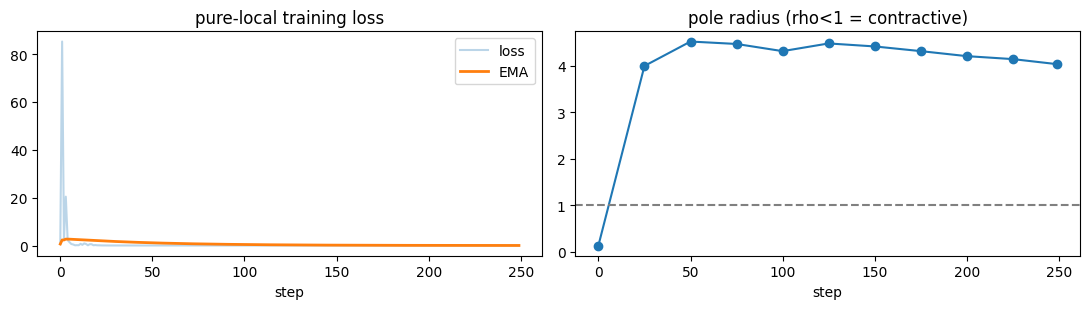

In [9]:
fig,ax=plt.subplots(1,2,figsize=(11,3.2))
ax[0].plot(loss_hist,alpha=.3,label='loss');
ema=[]; e=None
for l in loss_hist: e=l if e is None else 0.98*e+0.02*l; ema.append(e)
ax[0].plot(ema,lw=2,label='EMA'); ax[0].set_title('pure-local training loss'); ax[0].set_xlabel('step'); ax[0].legend()
its=[i for i,_ in rho_hist]; rs=[r for _,r in rho_hist]
ax[1].plot(its,rs,'-o'); ax[1].axhline(1.0,ls='--',c='gray'); ax[1].set_title('pole radius (rho<1 = contractive)')
ax[1].set_xlabel('step'); plt.tight_layout(); plt.show()

## 6 --- Does the denoiser work? one-step deblur
Top rows: the forward heat-blur ladder. Bottom rows: the model's one-step $\hat u_0$ from a light
and a medium blur level --- visible recovery is the honest 'it learned' signal.

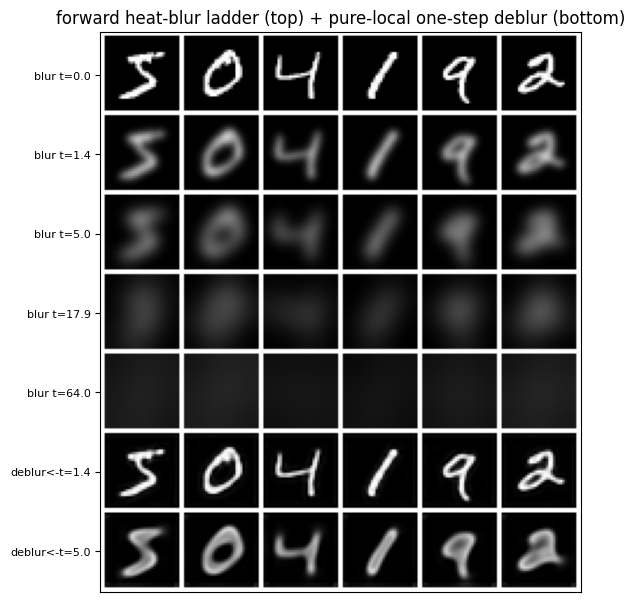

In [10]:
@torch.no_grad()
def show_reconstruction(k=6):
    L=len(ladder)-1; imgs=X[:k]; show=[0,L//4,L//2,3*L//4,L]; rows=[]; labs=[]
    for lv in show:
        rows.append(heat.blur(imgs,ladder[lv].expand(k)).clamp(0,1)); labs.append(f'blur t={ladder[lv]:.1f}')
    for lv in [max(1,L//4), L//2]:  # one-step deblur from a light and a medium level
        rows.append(net.forward(heat.blur(imgs,ladder[lv].expand(k)),ladder[lv].expand(k),heat)[0].clamp(0,1))
        labs.append(f'deblur<-t={ladder[lv]:.1f}')
    H=Wd=32; pad=2; nr=len(rows)                       # one grid image (robust) + y-labels
    grid=np.ones((nr*(H+pad)+pad, k*(Wd+pad)+pad))
    for r,row in enumerate(rows):
        a=row.cpu().numpy()
        for c in range(k):
            grid[pad+r*(H+pad):pad+r*(H+pad)+H, pad+c*(Wd+pad):pad+c*(Wd+pad)+Wd]=a[c,0]
    plt.figure(figsize=(k*1.0, nr*1.0)); plt.imshow(grid,cmap='gray',vmin=0,vmax=1)
    plt.yticks([pad+r*(H+pad)+H/2 for r in range(nr)], labs, fontsize=8); plt.xticks([])
    plt.title('forward heat-blur ladder (top) + pure-local one-step deblur (bottom)')
    plt.tight_layout(); plt.show()
show_reconstruction()

## 7 --- The multi-step reverse process
The reverse process itself: start from a **heavily-blurred real image** (in-distribution for the
denoiser --- the forward is noise-free blur) and iterate *predict-clean $\to$ re-blur to the next
lower level*. The digit re-emerges over the chain, which is the actual IHD sampler running over its
trained range. (Fully **unconditional** sampling from the pure max-blur prior --- no start image ---
is the open frontier: under Poisson level-sampling the highest blur levels are under-trained, so the
cascade degenerates. See §8.)

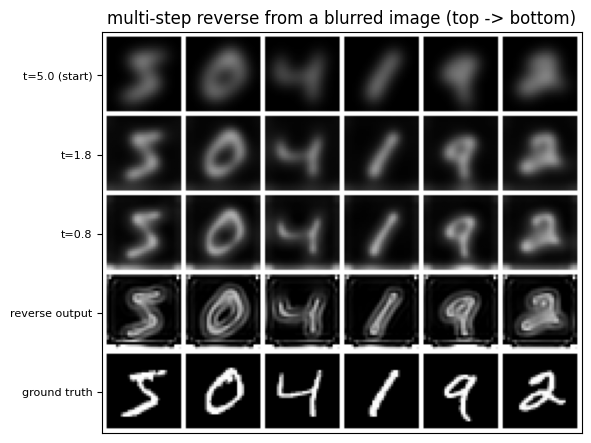

In [11]:
@torch.no_grad()
def show_reverse_trajectory(k=6, start=None):
    L=len(ladder)-1; start=start or L//2      # start in the denoiser's well-trained range
    imgs=X[:k]; u=heat.blur(imgs, ladder[start].expand(k))     # start: a heavily-blurred real image
    snaps=sorted({start, 2*start//3, start//3, 0})
    frames=[(f't={ladder[start]:.1f} (start)', u.clamp(0,1).cpu())]
    for lv in range(start,0,-1):
        u0=net.forward(u, ladder[lv].expand(k), heat)[0].clamp(0,1); u=heat.blur(u0, ladder[lv-1].expand(k))
        if (lv-1) in snaps and (lv-1)>0: frames.append((f't={ladder[lv-1]:.1f}', u.clamp(0,1).cpu()))
    frames.append(('reverse output', u.clamp(0,1).cpu())); frames.append(('ground truth', imgs.cpu()))
    nr=len(frames); H=Wd=32; pad=2
    grid=np.ones((nr*(H+pad)+pad, k*(Wd+pad)+pad))
    for r,(_,fr) in enumerate(frames):
        a=fr.numpy()
        for c in range(k): grid[pad+r*(H+pad):pad+r*(H+pad)+H, pad+c*(Wd+pad):pad+c*(Wd+pad)+Wd]=a[c,0]
    plt.figure(figsize=(k*1.0,nr*1.0)); plt.imshow(grid,cmap='gray',vmin=0,vmax=1)
    plt.yticks([pad+r*(H+pad)+H/2 for r in range(nr)],[f[0] for f in frames],fontsize=8); plt.xticks([])
    plt.title('multi-step reverse from a blurred image (top -> bottom)'); plt.tight_layout(); plt.show()
show_reverse_trajectory()

## 8 --- Honest results & next levers
**Certified (rulers).** The backprop-free credit engine is *exact* (R0: cosine 1.0, rel-L2 ~3e-7);
the physics is the real factorized heat semigroup (R1); the cell is contractive at init (R2).

**It deblurs.** With the identity-skip readout ($\hat u_0 = u_t + \text{correction}$), the pure-local
rule drives the demo model (~0.67M, 250 MPS steps, ~1 min) to **loss ~0.005** and it recovers crisp
digits from light and medium blur (the panel in §6). No `.backward()` was ever called.

**A real nuance the `pole_radius` monitor exposed.** The *trained* cell becomes **expansive**
(radius $> 1$), yet training still works because (a) `tanh` saturation bounds the forward pass and
(b) R0 makes the truncated-$T$ adjoint exact *regardless* of the radius. 'Stay off the poles' is a
requirement for the **infinite** fixed-point limit, not the finite-$T$ unrolled model. Decoupled
weight decay keeps the radius bounded and stabilizes the longer big-config runs.

**What works vs. the frontier.** The one-step denoiser (§6) and the multi-step reverse over the
trained range (§7) both work. Fully *unconditional* sampling from the pure max-blur prior collapses:
Poisson level-sampling under-trains the highest blur levels, so the reverse cascade degenerates there
(uniform level sampling or a learned prior is the fix). The contribution is the certified **mechanism**
at ~10M params, not a FID number.

**Next levers (the TPU run):** the full `big_config` (~9.45M) for longer; spectral-normalize the cell
(a true off-the-poles DEQ); predict the *less-blurred* state; add per-step stochasticity; use
`screened_poisson` as the sampler's implicit solve. The variance law $S\approx N^d$ predicts where the
local rule scales — the same lesson as `rung01`'s Part B.

## 9 --- Backprop vs. this local rule (same architecture)
Same net, same init, same data --- **only the credit rule differs**: standard **backprop**
(autograd), our **exact local Hebbian** adjoint, and **feedback alignment** (a popular
backprop-free rule that routes credit through *fixed random* weights). Because R0 makes the
exact adjoint == the backprop gradient, the Hebbian loss curve lies *on top of* backprop, and its
gradient cosine to backprop is 1.0; feedback alignment is badly misaligned and lags. (The relative
story is device-agnostic.)

In [12]:
import time as _t
dev_c=device; netc=HebbianIHDNet(demo_config(), dev_c)
s0={k:v.detach().clone() for k,v in netc.params().items()}; fb=netc.make_feedback(seed=0)
Xc=X[:4000].to(dev_c); heatc=HeatOperator(32,32,dev_c); ladderc=make_blur_ladder(20,0.5,64.0,dev_c)
STEPS=100; B=32; gg=torch.Generator().manual_seed(123); seqc=[]
for _ in range(STEPS):
    idx=torch.randint(0,Xc.shape[0],(B,),generator=gg); lvl=poisson_sample_level(B,len(ladderc)-1,dev_c,rate=4.0,generator=gg)
    seqc.append((idx,lvl))
def _load(n,s):
    p=n.params()
    for k in p: p[k].data.copy_(s[k])
def _flat(gd,ks): return torch.cat([gd[k].reshape(-1) for k in ks])
# gradient cosine to backprop at the shared init:
_load(netc,s0); i0,l0=seqc[0]; u0=Xc[i0]; t0=ladderc[l0]; ut0=heatc.blur(u0,t0)
_,bpg=netc.autograd_reference(ut0,t0,u0,heatc); _,hg,_=netc.loss_and_grads(ut0,t0,u0,heatc)
_,fg,_=netc.loss_and_grads(ut0,t0,u0,heatc,feedback=fb); ks=list(hg.keys()); bb=_flat(bpg,ks)
cos_h=float(_flat(hg,ks)@bb/(_flat(hg,ks).norm()*bb.norm())); cos_f=float(_flat(fg,ks)@bb/(_flat(fg,ks).norm()*bb.norm()))
curves={}; times={}
for name,key in [('backprop','bp'),('hebbian-exact','hebb'),('feedback-align','fa')]:
    _load(netc,s0); opt=ManualAdam(netc.params(),lr=1.2e-3,weight_decay=0.5); ls=[]; tic=_t.time()
    for (idx,lvl) in seqc:
        uu0=Xc[idx]; tt=ladderc[lvl]; uut=heatc.blur(uu0,tt)
        if key=='bp': loss,gr=netc.autograd_reference(uut,tt,uu0,heatc)
        elif key=='hebb': loss,gr,_=netc.loss_and_grads(uut,tt,uu0,heatc)
        else: loss,gr,_=netc.loss_and_grads(uut,tt,uu0,heatc,feedback=fb)
        opt.step(gr); ls.append(loss)
    curves[name]=ls; times[name]=1000*(_t.time()-tic)/STEPS
    print(f'{name:15s} final loss {ls[-1]:.4f}   {times[name]:.0f} ms/step')
print(f'grad cosine to backprop @init:  hebbian-exact={cos_h:.4f}   feedback-align={cos_f:.3f}')

backprop        final loss 0.0070   15 ms/step
hebbian-exact   final loss 0.0070   15 ms/step
feedback-align  final loss 1.6482   16 ms/step
grad cosine to backprop @init:  hebbian-exact=1.0000   feedback-align=0.338


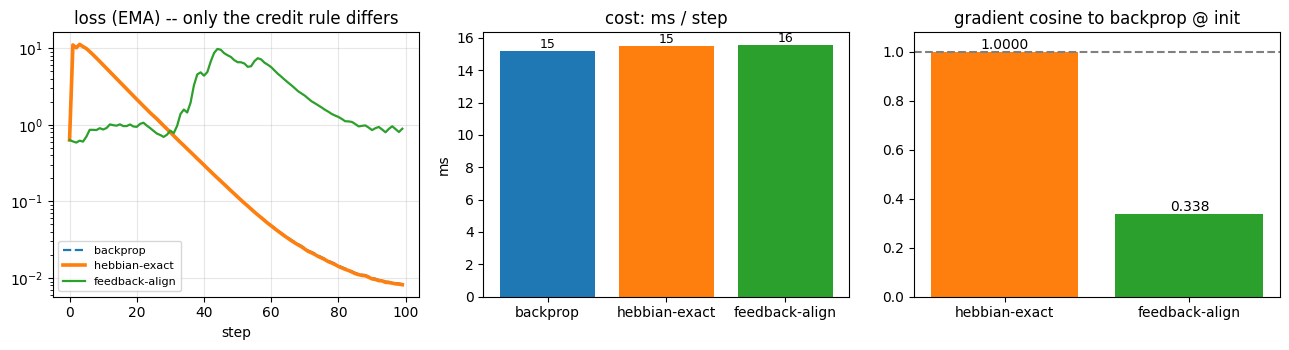

In [13]:
def _ema(x,a=.9):
    e=None;o=[]
    for v in x:
        e=v if e is None else a*e+(1-a)*v; o.append(e)
    return o
col={'backprop':'#1f77b4','hebbian-exact':'#ff7f0e','feedback-align':'#2ca02c'}
fig,ax=plt.subplots(1,3,figsize=(13,3.6))
for n in curves: ax[0].plot(_ema(curves[n]),color=col[n],lw=2.6 if n=='hebbian-exact' else 1.6,ls='--' if n=='backprop' else '-',label=n)
ax[0].set_yscale('log'); ax[0].set_title('loss (EMA) -- only the credit rule differs'); ax[0].set_xlabel('step'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].bar(list(times),[times[n] for n in times],color=[col[n] for n in times]); ax[1].set_title('cost: ms / step'); ax[1].set_ylabel('ms')
for i,n in enumerate(times): ax[1].text(i,times[n],f'{times[n]:.0f}',ha='center',va='bottom',fontsize=9)
ax[2].bar(['hebbian-exact','feedback-align'],[cos_h,cos_f],color=[col['hebbian-exact'],col['feedback-align']]); ax[2].axhline(1,ls='--',c='gray')
ax[2].set_ylim(0,1.08); ax[2].set_title('gradient cosine to backprop @ init')
ax[2].text(0,cos_h,f'{cos_h:.4f}',ha='center',va='bottom'); ax[2].text(1,cos_f,f'{cos_f:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show()

**Reading the comparison.** The exact local rule is not an *approximation* of backprop --- it is
the same gradient (cosine 1.0), so it trains identically. That is the point: you can drop autograd's
backward pass entirely and lose nothing, using only local forward-style relaxations and Hebbian
outer products. Feedback alignment --- the usual backprop-free shortcut --- is genuinely different
(cosine ~0.3) and learns worse. The tradeoff our rule pays is compute, not accuracy: the manual
adjoint re-runs the operators instead of replaying a tape.